<div class="alert alert-block alert-success">
<b>NOTEBOOK 4 - Clustering
</div>

---
# 1 - IMPORTS

### 1.1 - SETUP PROJECT

Make sure to check `README.md` and `requirements.txt` before running any notebooks. 

In [85]:
# Import modules
import sys
import importlib
import pandas as pd
from pathlib import Path

### 1.2 - DEFINE PATHS

In [86]:
# Paths
PROJECT_PATH = Path.cwd().resolve().parent
DATA_PATH = PROJECT_PATH / "data"
RAW_DATA_PATH = DATA_PATH / "raw"
META_PATH = DATA_PATH / "meta"
INTERIM_DATA_PATH = DATA_PATH / "interim"
SRC_PATH = PROJECT_PATH / "src"
UTILS_PATH = SRC_PATH / "utilities"
PROCESSED_PATH = DATA_PATH / "processed"

# Add src to sys.path (for package-style imports)
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# Add utilities folder to sys.path (for direct import utils)
if str(UTILS_PATH) not in sys.path:
    sys.path.append(str(UTILS_PATH))


# Import with reload
try:
    import utilities.utils as utils
except ModuleNotFoundError:
    import utils

reimport = importlib.reload(utils)

### 1.3 - LOAD DATASET

In [87]:
# Load Data

# Clustering
file_path_c = PROCESSED_PATH / "01_climate_dataset_forClustering_scaled.xlsx"
cluster_df = pd.read_excel(file_path_c, sheet_name=None)["Sheet1"]

# Descriptive stats
file_path_d = PROCESSED_PATH / "01_climate_dataset_descriptive_features.xlsx"
desc_df = pd.read_excel(file_path_d, sheet_name=None)["Sheet1"]

# Display both
display(cluster_df.head())
display(desc_df.head()) 

,environmental_concerns,adaptation_engagement_score,climate_event_count,flood_experience,heat_experience,climate_consequence_count,infra_consequences,health_consequences,climate_concern,personal_preparedness_score,domestic_responsibility,global_solidarity
0,0.589000,0.828392,-1.409182,-0.567508,-1.302699,-1.120094,-0.739279,-0.552901,-0.911461,-0.283552,0.454515,-0.439228
1,0.589000,0.828392,-0.754594,-0.567508,-1.302699,-0.422716,-0.739279,-0.552901,-0.150274,0.682057,-0.310345,0.707771
2,-0.961162,0.828392,-0.100006,-0.567508,0.773381,-1.120094,-0.739279,-0.552901,-0.911461,1.647667,1.984234,0.707771
3,-0.961162,-0.292439,0.554581,1.378235,-0.264659,-1.120094,-0.739279,-0.552901,-1.672648,1.647667,-1.075204,0.707771
4,-0.961162,-0.292439,-0.754594,-0.567508,-0.264659,0.972040,0.532382,1.808642,-0.150274,-0.283552,0.454515,-0.439228


,gender,age_group,kids,education,net_income,political_preference,housing_status,living_area
0,0,5,2,2,10,7,2,1
1,0,5,2,3,1,6,1,2
2,1,3,2,2,1,10,2,3
3,0,3,2,3,11,5,2,2
4,1,3,2,3,9,12,2,1


---
# 2 - CLUSTERING

Shapes -> X: (1008, 12) | cluster_df: (1008, 12) | desc_df: (1008, 8)
PCA(2) explained variance: 0.406
PCA(≥95%) components: 10 | variance: 0.973


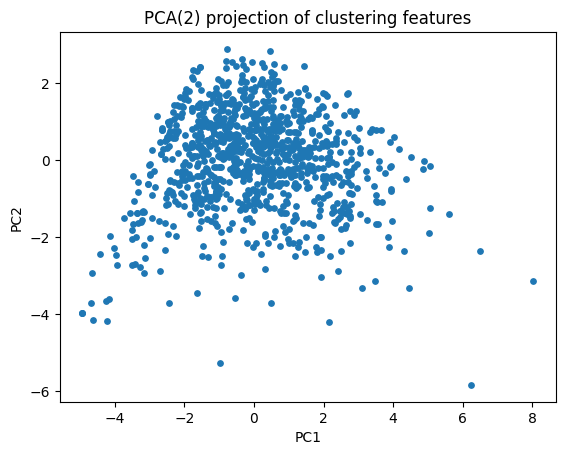

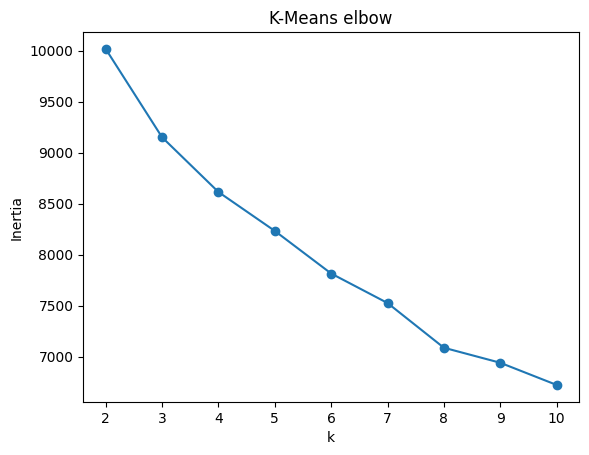

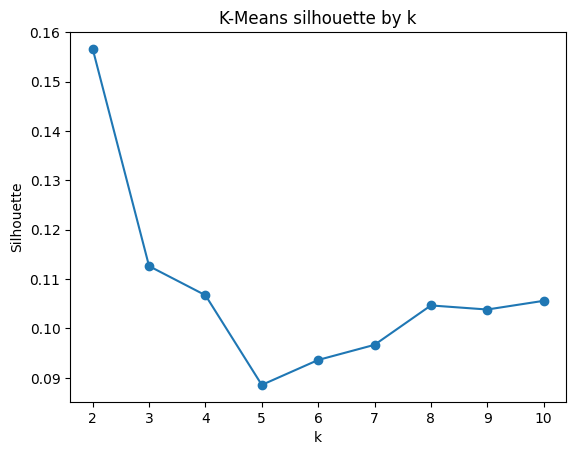

[K-Means] k=4 | silhouette=0.107


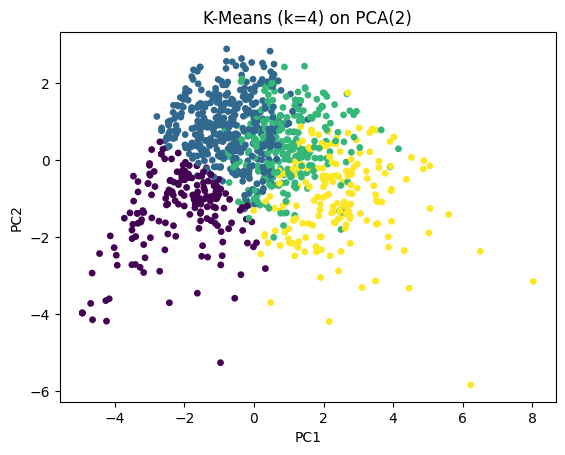

[Hierarchical] k=4, linkage='ward' | silhouette=0.062


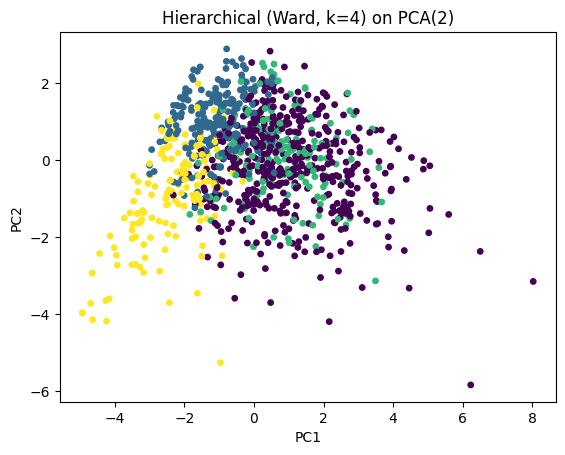

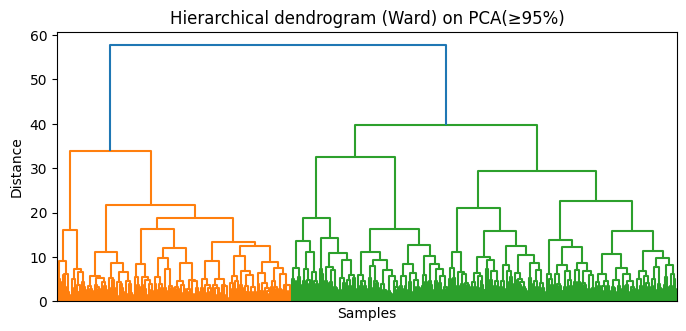

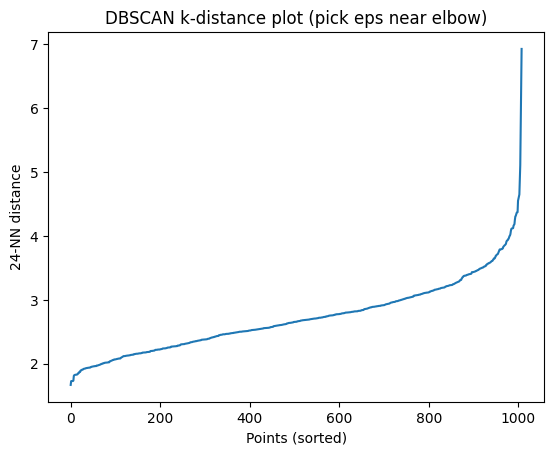


DBSCAN scan (quantiles of k-distance):
    q       eps  clusters  noise silhouette
0  85  3.247178         1     23       None
1  90  3.453618         1     11       None
2  92  3.527429         1      8       None
3  94  3.648130         1      7       None
4  95  3.767256         1      5       None
5  96  3.834028         1      4       None
6  97  3.945800         1      3       None
7  98  4.119337         1      2       None
8  99  4.366463         1      1       None

[DBSCAN] No setting produced ≥2 clusters with computable silhouette. Keeping last attempt for plotting.

[DBSCAN] clusters=1, noise=5, silhouette=None


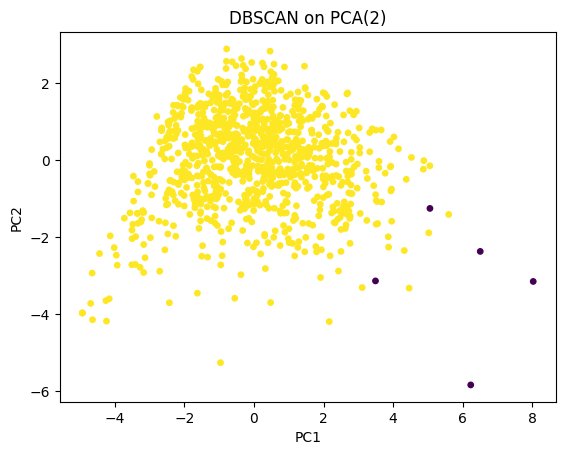


=== Algorithm comparison ===
             algorithm                    params  clusters  noise  silhouette
0              K-Means                       k=4         4      0    0.106733
1  Hierarchical (Ward)                       k=4         4      0    0.062394
2               DBSCAN  eps≈auto, min_samples=24         1      5         NaN

=== K-Means (k=6) cluster sizes ===
0    179
1    394
2    253
3    182
Name: count, dtype: int64

=== Descriptive means by K-Means cluster ===
                gender  age_group   kids  education  net_income  \
cluster_kmeans                                                    
0                0.486      3.575  1.749      2.240       6.285   
1                0.533      3.635  1.741      2.201       6.766   
2                0.549      3.514  1.767      2.233       6.431   
3                0.582      3.038  1.615      2.379       6.918   

                political_preference  housing_status  living_area  
cluster_kmeans                            

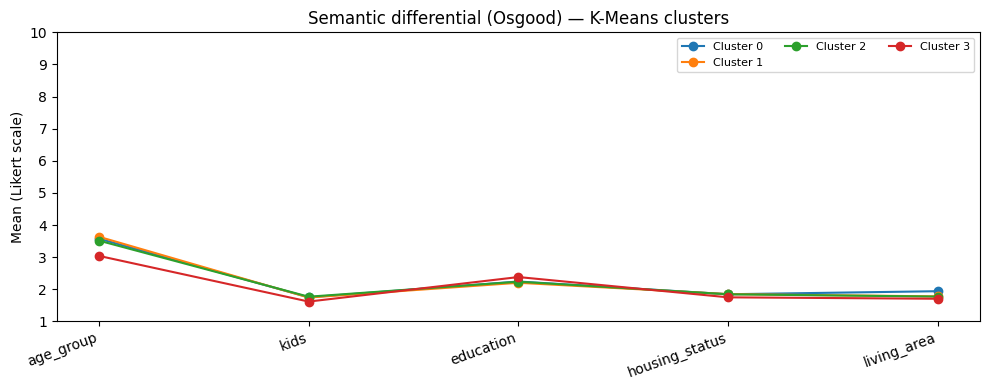


Done.


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram



# Keep numeric feature matrix
X = cluster_df.select_dtypes(include=[np.number]).to_numpy()
feature_names = cluster_df.select_dtypes(include=[np.number]).columns.tolist()

print("Shapes -> X:", X.shape, "| cluster_df:", cluster_df.shape, "| desc_df:", desc_df.shape)

# ---------- PCA for visualization + explained variance ----------
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X)
evr_2 = pca2.explained_variance_ratio_.sum()

pca95 = PCA(n_components=0.95, svd_solver="full", random_state=42)
X_95 = pca95.fit_transform(X)
evr_95 = pca95.explained_variance_ratio_.sum()

print(f"PCA(2) explained variance: {evr_2:.3f}")
print(f"PCA(≥95%) components: {X_95.shape[1]} | variance: {evr_95:.3f}")

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1], s=15)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("PCA(2) projection of clustering features")
plt.show()

# ---------- K-Means: elbow + silhouette sweep ----------
inertias = []
silhouettes_k = []
k_values = range(2, 11)
for k in k_values:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    lab = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes_k.append(silhouette_score(X, lab))

plt.figure()
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("k"); plt.ylabel("Inertia")
plt.title("K-Means elbow")
plt.xticks(list(k_values))
plt.show()

plt.figure()
plt.plot(list(k_values), silhouettes_k, marker="o")
plt.xlabel("k"); plt.ylabel("Silhouette")
plt.title("K-Means silhouette by k")
plt.xticks(list(k_values))
plt.show()

# ---------- Final K-Means (k=4) ----------
k_kmeans = 4
kmeans = KMeans(n_clusters=k_kmeans, n_init="auto", random_state=42)
labels_km = kmeans.fit_predict(X)
sil_km = silhouette_score(X, labels_km)
print(f"[K-Means] k={k_kmeans} | silhouette={sil_km:.3f}")

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_km, s=15)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"K-Means (k={k_kmeans}) on PCA(2)")
plt.show()

# ---------- Hierarchical (Ward, k=6) ----------
hier = AgglomerativeClustering(n_clusters=k_kmeans, linkage='ward')
labels_hc = hier.fit_predict(X)
sil_hc = silhouette_score(X, labels_hc)
print(f"[Hierarchical] k={k_kmeans}, linkage='ward' | silhouette={sil_hc:.3f}")

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_hc, s=15)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title(f"Hierarchical (Ward, k={k_kmeans}) on PCA(2)")
plt.show()

# Optional: Dendrogram (on a PCA-reduced space to keep it readable)
Z = linkage(X_95, method="ward")
plt.figure(figsize=(8, 3.5))
dendrogram(Z, no_labels=True, count_sort=True)
plt.title("Hierarchical dendrogram (Ward) on PCA(≥95%)")
plt.xlabel("Samples"); plt.ylabel("Distance")
plt.show()

# ---------- DBSCAN: k-distance elbow + quantile sweep ----------
min_samples = max(5, 2 * X.shape[1])  # sturdy heuristic
nn = NearestNeighbors(n_neighbors=min_samples).fit(X)
dists, _ = nn.kneighbors(X)
k_dists = np.sort(dists[:, -1])

plt.figure()
plt.plot(k_dists)
plt.ylabel(f"{min_samples}-NN distance"); plt.xlabel("Points (sorted)")
plt.title("DBSCAN k-distance plot (pick eps near elbow)")
plt.show()

quantiles = [85, 90, 92, 94, 95, 96, 97, 98, 99]
dbscan_rows = []
labels_db_best = None
best_sil = -np.inf
best_idx = None

for q in quantiles:
    eps = float(np.percentile(k_dists, q))
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels_db = db.fit_predict(X)

    # number of clusters excluding noise (-1)
    n_clu = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = int((labels_db == -1).sum())

    # safe silhouette (require >= 2 clusters; compute on non-noise)
    sil_val = None
    if n_clu >= 2:
        mask = labels_db != -1
        if mask.sum() > 1 and len(set(labels_db[mask])) >= 2:
            sil_val = silhouette_score(X[mask], labels_db[mask])

    dbscan_rows.append({"q": q, "eps": eps, "clusters": n_clu, "noise": n_noise, "silhouette": sil_val})

    if sil_val is not None and sil_val > best_sil:
        best_sil = sil_val
        labels_db_best = labels_db
        best_idx = len(dbscan_rows) - 1

dbscan_df = pd.DataFrame(dbscan_rows)
print("\nDBSCAN scan (quantiles of k-distance):")
print(dbscan_df)

if labels_db_best is None:
    print("\n[DBSCAN] No setting produced ≥2 clusters with computable silhouette. Keeping last attempt for plotting.")
    labels_db = DBSCAN(eps=float(np.percentile(k_dists, 95)), min_samples=min_samples).fit_predict(X)
else:
    labels_db = labels_db_best

n_dbscan_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_dbscan_noise = int((labels_db == -1).sum())
sil_db = None
if n_dbscan_clusters >= 2:
    mask = labels_db != -1
    if mask.sum() > 1 and len(set(labels_db[mask])) >= 2:
        sil_db = silhouette_score(X[mask], labels_db[mask])

print(f"\n[DBSCAN] clusters={n_dbscan_clusters}, noise={n_dbscan_noise}, silhouette={sil_db}")

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1], c=labels_db, s=15)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("DBSCAN on PCA(2)")
plt.show()

# ---------- Side-by-side comparison table ----------
comp = pd.DataFrame([
    {"algorithm": "K-Means", "params": f"k={k_kmeans}", "clusters": len(np.unique(labels_km)), "noise": 0, "silhouette": sil_km},
    {"algorithm": "Hierarchical (Ward)", "params": f"k={k_kmeans}", "clusters": len(np.unique(labels_hc)), "noise": 0, "silhouette": sil_hc},
    {"algorithm": "DBSCAN", "params": f"eps≈auto, min_samples={min_samples}", "clusters": n_dbscan_clusters, "noise": n_dbscan_noise, "silhouette": sil_db},
])
print("\n=== Algorithm comparison ===")
print(comp)

# ---------- Attach labels back to dataframes ----------
cluster_df_out = cluster_df.copy()
cluster_df_out["cluster_kmeans"] = labels_km
cluster_df_out["cluster_hier"]   = labels_hc
cluster_df_out["cluster_dbscan"] = labels_db

# line up with desc_df by index (assumes same row order)
desc_df_out = desc_df.copy()
desc_df_out["cluster_kmeans"] = labels_km
desc_df_out["cluster_hier"]   = labels_hc
desc_df_out["cluster_dbscan"] = labels_db

# ---------- Descriptive stats by K-Means cluster ----------
print("\n=== K-Means (k=6) cluster sizes ===")
print(pd.Series(labels_km).value_counts().sort_index())

# numeric means per cluster for descriptive features
desc_num_cols = desc_df_out.select_dtypes(include=[np.number]).columns.tolist()
if "cluster_kmeans" in desc_num_cols:
    desc_num_cols.remove("cluster_kmeans")
if "cluster_hier" in desc_num_cols:
    desc_num_cols.remove("cluster_hier")
if "cluster_dbscan" in desc_num_cols:
    desc_num_cols.remove("cluster_dbscan")

print("\n=== Descriptive means by K-Means cluster ===")
print(desc_df_out.groupby("cluster_kmeans")[desc_num_cols].mean().round(3))

print("\n=== Descriptive std by K-Means cluster ===")
print(desc_df_out.groupby("cluster_kmeans")[desc_num_cols].std().round(3))

# For categorical columns, show top categories per cluster (first few columns to limit spam)
desc_cat_cols = [c for c in desc_df_out.columns if c not in desc_num_cols + ["cluster_kmeans","cluster_hier","cluster_dbscan"]]
desc_cat_cols = [c for c in desc_cat_cols if desc_df_out[c].dtype == "object"]
for c in desc_cat_cols[:5]:
    print(f"\n--- {c}: top categories per K-Means cluster ---")
    print(desc_df_out.groupby("cluster_kmeans")[c].agg(lambda s: s.value_counts().head(3)).to_string())

# ---------- Semantic differential (Osgood-style) ----------
# 1) Pick Osgood/Likert attributes to plot (set your exact column names here).
osgood_cols = []  # e.g.: ["climate_concern", "preparedness", "domestic_responsibility", "global_solidarity", ...]
# If you didn't set them, try to auto-guess Likert-y numeric columns in [1..10]
if len(osgood_cols) == 0:
    cand = []
    for c in desc_num_cols:
        col = desc_df_out[c].dropna()
        if col.size >= 10:
            mn, mx = col.min(), col.max()
            if mn >= 1 and mx <= 10:
                cand.append(c)
    osgood_cols = cand[:8]  # cap to 8 to keep the plot readable

print("\n[Osgood] Using attributes:", osgood_cols)

# 2) Compute per-cluster means (K-Means clusters)
osgood_means = desc_df_out.groupby("cluster_kmeans")[osgood_cols].mean()

# 3) Draw one semantic differential plot:
#    x-axis = attributes, y-axis = mean score (1..10). One line per cluster.
plt.figure(figsize=(10, 4))
x = np.arange(len(osgood_cols))
for cl in sorted(osgood_means.index):
    plt.plot(x, osgood_means.loc[cl].values, marker="o", label=f"Cluster {cl}")
plt.xticks(x, osgood_cols, rotation=20, ha="right")
plt.ylim(1, 10)
plt.ylabel("Mean (Likert scale)")
plt.title("Semantic differential (Osgood) — K-Means clusters")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

# ---------- Optional: Save artifacts ----------
# cluster_df_out.to_excel("clusters_with_labels.xlsx", index=False)
# comp.to_csv("clustering_comparison.csv", index=False)

print("\nDone.")


### 2.1 - SCALING CLUSTER FEATURES

Explained variance ratio: 0.4057813316205919


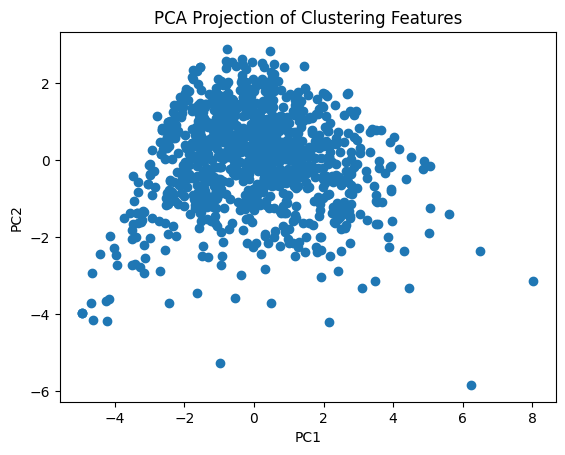

In [89]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA
pca = PCA(n_components=2)  # 2D for visualization
cluster_pca = pca.fit_transform(cluster_df)

print("Explained variance ratio:", pca.explained_variance_ratio_.sum())

# Scatter plot
plt.scatter(cluster_pca[:,0], cluster_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Clustering Features")
plt.show()


In [90]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

X = cluster_df.values

# K-Means
kmeans = KMeans(n_clusters=6, random_state=42)
labels_km = kmeans.fit_predict(X)
print("K-Means Silhouette:", silhouette_score(X, labels_km))

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)  # tune eps
labels_db = dbscan.fit_predict(X)
print("DBSCAN Silhouette:", silhouette_score(X, labels_db))

# Hierarchical
hier = AgglomerativeClustering(n_clusters=6, linkage='ward')
labels_hc = hier.fit_predict(X)
print("Hierarchical Silhouette:", silhouette_score(X, labels_hc))


K-Means Silhouette: 0.09361486472547373
DBSCAN Silhouette: -0.20962564098051054
Hierarchical Silhouette: 0.08509218898565825


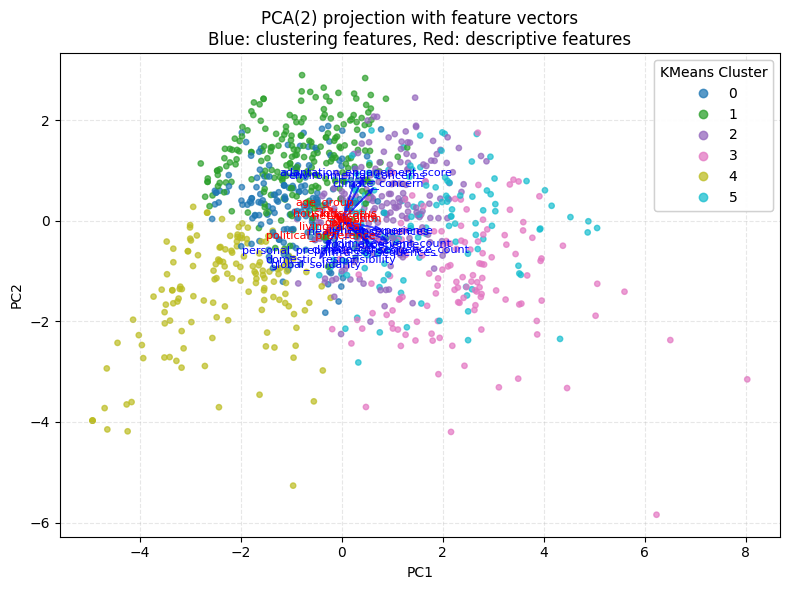

In [91]:
import matplotlib.pyplot as plt

# Use the 2D PCA projection from X_2d and the KMeans cluster labels
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot of samples colored by KMeans cluster
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_km, cmap='tab10', s=15, alpha=0.7)
legend1 = ax.legend(*scatter.legend_elements(), title="KMeans Cluster")
ax.add_artist(legend1)

# Plot clustering features as vectors (blue)
for i, fname in enumerate(feature_names):
    # Vector direction: PCA components (feature loading)
    vec = pca2.components_[:, i] * 2  # scale for visibility
    ax.arrow(0, 0, vec[0], vec[1], color='blue', alpha=0.7, head_width=0.08, length_includes_head=True)
    ax.text(vec[0]*1.15, vec[1]*1.15, fname, color='blue', fontsize=8, ha='center', va='center')

# Plot descriptive features as vectors (red)
desc_features = desc_num_cols
for i, fname in enumerate(desc_features):
    # Compute correlation of each descriptive feature with the two PCA axes
    # Use desc_df_out to align with cluster_df_out
    if fname in desc_df_out.columns:
        v = desc_df_out[fname].values
        # Correlation with PC1 and PC2
        corr1 = np.corrcoef(v, X_2d[:, 0])[0, 1]
        corr2 = np.corrcoef(v, X_2d[:, 1])[0, 1]
        # Scale for visibility
        ax.arrow(0, 0, corr1*2, corr2*2, color='red', alpha=0.7, head_width=0.08, length_includes_head=True)
        ax.text(corr1*2.3, corr2*2.3, fname, color='red', fontsize=8, ha='center', va='center')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA(2) projection with feature vectors\nBlue: clustering features, Red: descriptive features")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
import numpy as np
import pandas as pd

# For each cluster, show the top contributing features (clustering and descriptive)

clustering_features = feature_names
clustering_means = cluster_df_out.groupby("cluster_kmeans")[clustering_features].mean()
overall_means = cluster_df_out[clustering_features].mean()

# Compute absolute difference from overall mean for each cluster
clustering_contrib = clustering_means.subtract(overall_means).abs()

# Show top 3 contributing clustering features per cluster
print("Top clustering features per cluster (by deviation from overall mean):")
for cl in clustering_contrib.index:
    top_feats = clustering_contrib.loc[cl].sort_values(ascending=False).head(5)
    print(f"Cluster {cl}:")
    for feat, val in top_feats.items():
        print(f"  {feat}: {val:.3f}")
    print()

# 2. For descriptive features: same logic
desc_features = desc_num_cols
desc_means = desc_df_out.groupby("cluster_kmeans")[desc_features].mean()
desc_overall = desc_df_out[desc_features].mean()
desc_contrib = desc_means.subtract(desc_overall).abs()

print("Top descriptive features per cluster (by deviation from overall mean):")
for cl in desc_contrib.index:
    top_feats = desc_contrib.loc[cl].sort_values(ascending=False).head(3)
    print(f"Cluster {cl}:")
    for feat, val in top_feats.items():
        print(f"  {feat}: {val:.3f}")
    print()

Top clustering features per cluster (by deviation from overall mean):
Cluster 0:
  climate_concern: 1.107
  adaptation_engagement_score: 1.069
  global_solidarity: 0.970
  personal_preparedness_score: 0.714
  environmental_concerns: 0.701

Cluster 1:
  heat_experience: 0.652
  climate_event_count: 0.647
  climate_consequence_count: 0.370
  flood_experience: 0.345
  infra_consequences: 0.320

Cluster 2:
  heat_experience: 0.983
  climate_event_count: 0.751
  climate_concern: 0.379
  domestic_responsibility: 0.298
  infra_consequences: 0.287

Cluster 3:
  infra_consequences: 1.539
  climate_consequence_count: 1.413
  climate_event_count: 0.950
  flood_experience: 0.790
  heat_experience: 0.631

Top descriptive features per cluster (by deviation from overall mean):
Cluster 0:
  political_preference: 1.111
  net_income: 0.339
  living_area: 0.148

Cluster 1:
  age_group: 0.148
  net_income: 0.142
  education: 0.048

Cluster 2:
  political_preference: 0.336
  net_income: 0.193
  kids: 0.041

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bin political_preference: 1-3 (left), 4-7 (center), 8-10 (right), 11-12 (no answer)
bins = [0, 3, 7, 10, 12]
labels = ['Left (1-3)', 'Center (4-7)', 'Right (8-10)', 'No answer (11-12)']
desc_df_out['political_group'] = pd.cut(
    desc_df_out['political_preference'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

# Crosstab: rows=political_group, columns=cluster_kmeans
ctab = pd.crosstab(desc_df_out['political_group'], desc_df_out['cluster_kmeans'])

# Normalize by row (each group sums to 1)
ctab_norm = ctab.div(ctab.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 4))
sns.heatmap(ctab_norm, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': '% in cluster'})
plt.title("Distribution of Political Groups Across Clusters\n(Row-normalized: % of group in each cluster)")
plt.ylabel("Political Group")
plt.xlabel("KMeans Cluster")
plt.tight_layout()
plt.show()

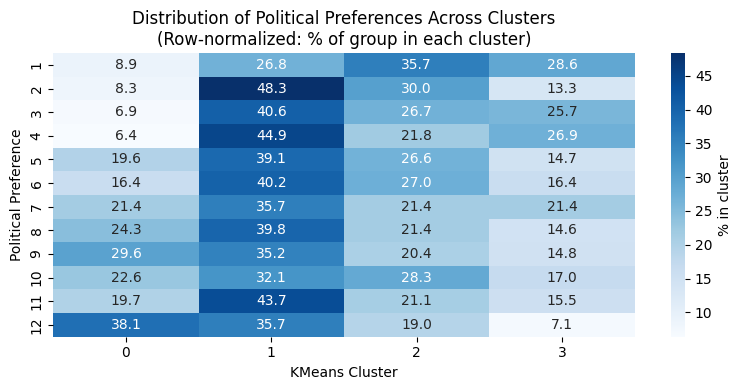

In [95]:
import seaborn as sns

import matplotlib.pyplot as plt

# Assume 'political_preference' is a column in desc_df_out and clusters are in 'cluster_kmeans'
# Create a crosstab: rows=political_preference, columns=cluster_kmeans
ctab = pd.crosstab(desc_df_out['political_preference'], desc_df_out['cluster_kmeans'])

# Normalize by row (each political group sums to 1)
ctab_norm = ctab.div(ctab.sum(axis=1), axis=0) * 100

plt.figure(figsize=(8, 4))
sns.heatmap(ctab_norm, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': '% in cluster'})
plt.title("Distribution of Political Preferences Across Clusters\n(Row-normalized: % of group in each cluster)")
plt.ylabel("Political Preference")
plt.xlabel("KMeans Cluster")
plt.tight_layout()
plt.show()